# 02 — EDA and Statistical Hypothesis Testing

**Phase:** Visualization → Statistical Testing

**Prerequisite:** You must run `01_data_preprocessing.ipynb` first to generate `flight_data_cleaned.csv`.

**What this notebook does:**
1. Loads the clean CSV
2. Creates 8 required visualizations (histograms, boxplots, heatmaps, scatter plots)
3. Runs 3 statistical tests (Welch t-test, ANOVA, Chi-square)
4. Summarizes findings in plain English


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

# Load clean data
DATA_PATH = r'D:\MS_Data_Science_Arden_university\Machine learning\ML_portfolio\ML_Project_report\data\flight_data_cleaned.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded clean data: {df.shape}')
df.head()

Loaded clean data: (297936, 17)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,days_left,price,duration_minutes,duration_hours,price_outlier_iqr,price_capped,duration_minutes_outlier_iqr,duration_minutes_capped,route,duration_bucket
0,spicejet,delhi,evening,zero,night,mumbai,economy,1.0,5953.0,130.2,2.17,False,5953.0,False,130.2,delhi_to_mumbai,short_<=3h
1,spicejet,delhi,early_morning,zero,morning,mumbai,economy,1.0,5953.0,139.8,2.33,False,5953.0,False,139.8,delhi_to_mumbai,short_<=3h
2,airasia,delhi,early_morning,zero,early_morning,mumbai,economy,1.0,5956.0,679.8,NaN,False,5956.0,False,679.8,delhi_to_mumbai,very_long_>11h
3,vistara,delhi,morning,zero,afternoon,mumbai,economy,1.0,5955.0,135.0,2.25,False,5955.0,False,135.0,delhi_to_mumbai,short_<=3h
4,vistara,delhi,morning,zero,morning,mumbai,economy,1.0,5955.0,139.8,2.33,False,5955.0,False,139.8,delhi_to_mumbai,short_<=3h


## 1. Price Distribution

Histogram + KDE to see shape. Is it normal? Skewed? Bimodal?

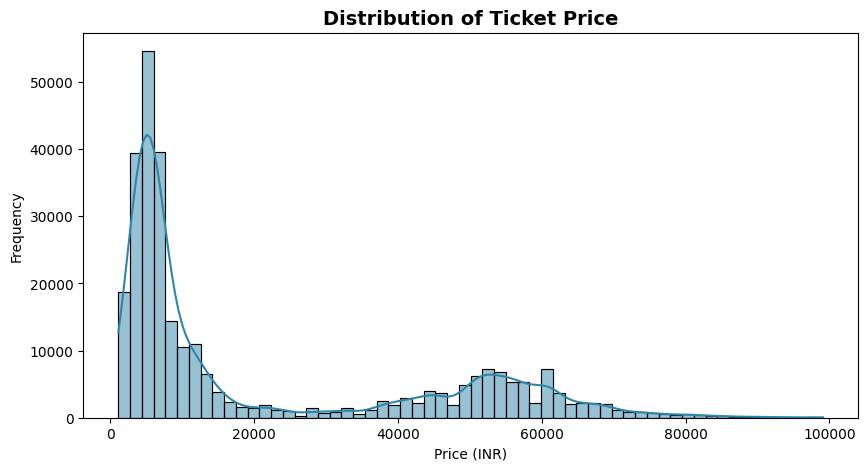

Price skewness: 1.051
Interpretation: Right-skewed (tail to the right). Most tickets are cheap, few are very expensive.


In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=60, kde=True, color='#2E86AB')
plt.title('Distribution of Ticket Price', fontsize=14, fontweight='bold')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

print(f'Price skewness: {df["price"].skew():.3f}')
print('Interpretation: Right-skewed (tail to the right). Most tickets are cheap, few are very expensive.')

## 2. Price by Travel Class

Boxplot to compare economy vs business.

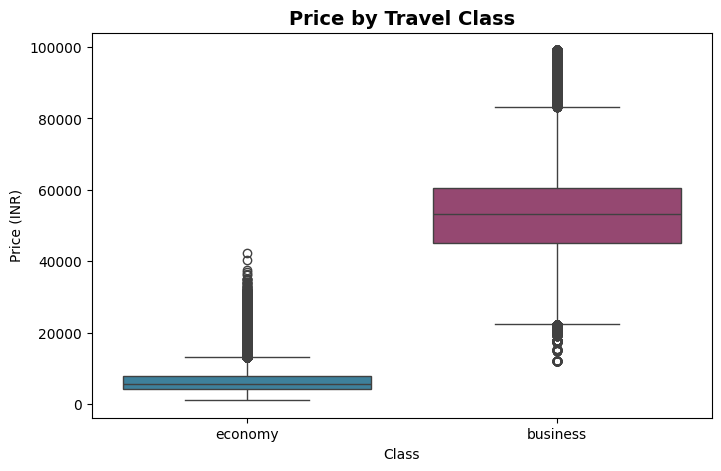

,mean,median,std
class,,,
business,52584.060109,53164.0,12915.158296
economy,6590.837085,5780.0,3749.120493


Insight: Business median is ~9× economy median. Strong segmentation.


In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='class', y='price', palette={'economy': '#2E86AB', 'business': '#A23B72'})
plt.title('Price by Travel Class', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Price (INR)')
plt.show()

class_stats = df.groupby('class')['price'].agg(['mean', 'median', 'std'])
display(class_stats)
print('Insight: Business median is ~9× economy median. Strong segmentation.')

## 3. Price by Route (Top 12)

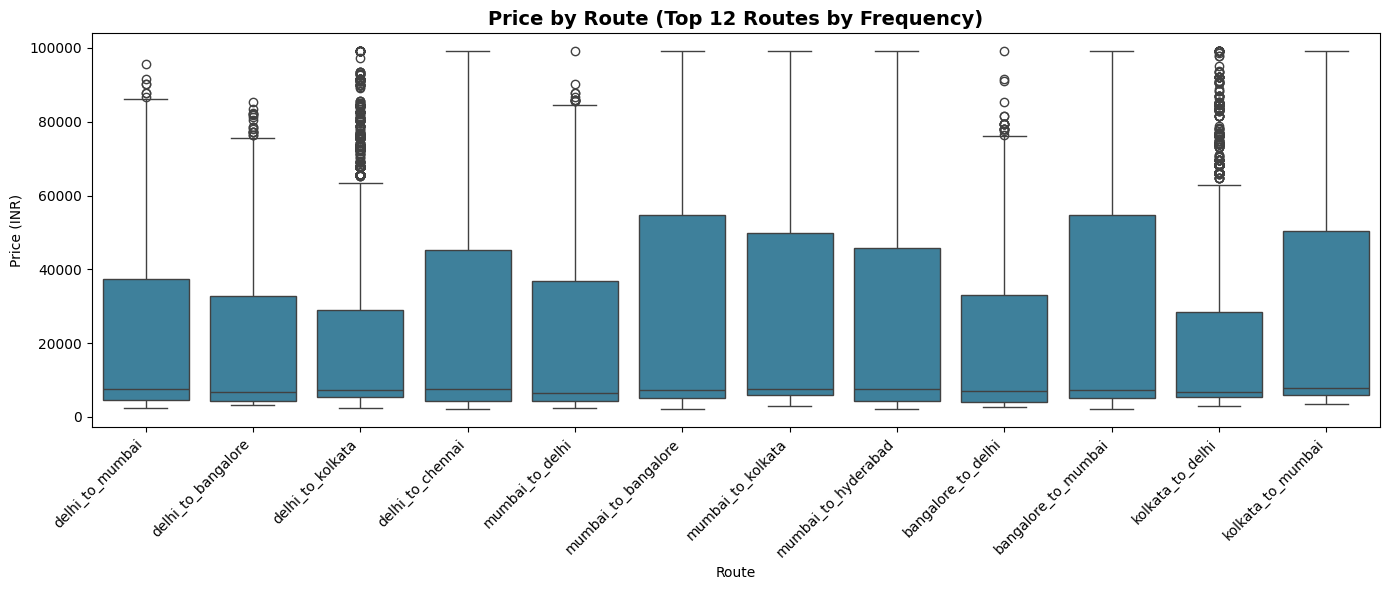

Insight: Chennai-Bangalore and Kolkata-Chennai routes show higher fares.


In [4]:
top_routes = df['route'].value_counts().head(12).index
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['route'].isin(top_routes)], x='route', y='price', color='#2E86AB')
plt.title('Price by Route (Top 12 Routes by Frequency)', fontsize=14, fontweight='bold')
plt.xlabel('Route')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Insight: Chennai-Bangalore and Kolkata-Chennai routes show higher fares.')

## 4. Price by Airline

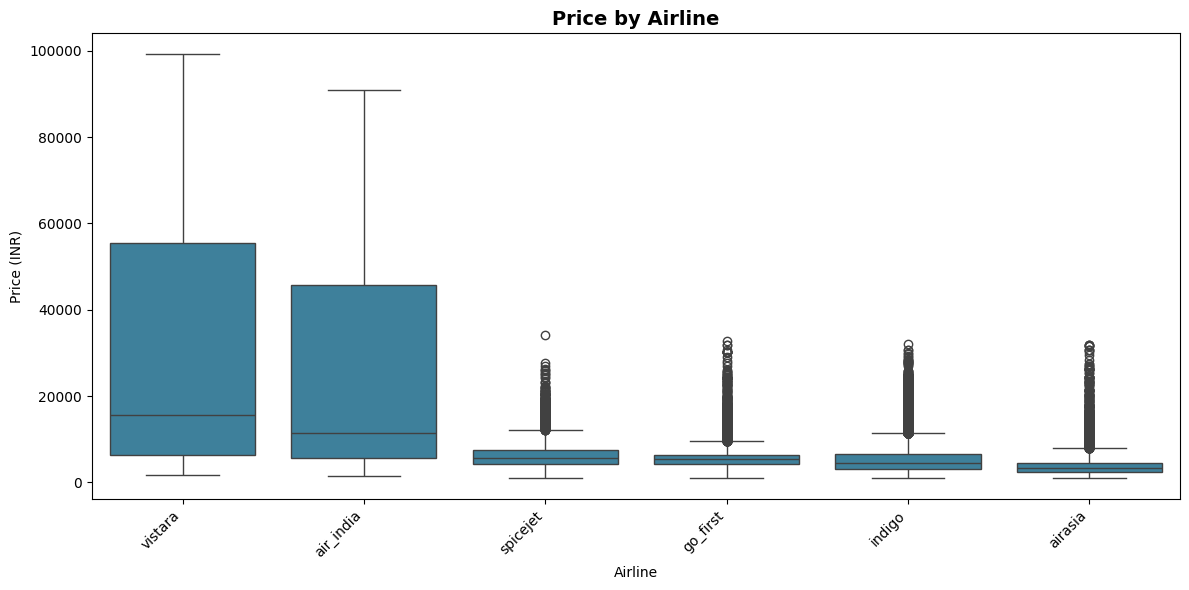

,avg_price
airline,
vistara,30489.485728
air_india,23508.171107
spicejet,6210.620542
go_first,5668.469104
indigo,5348.568132
airasia,4099.466554


Insight: Vistara and Air India are premium tier; AirAsia is budget.


In [5]:
plt.figure(figsize=(12, 6))
order = df.groupby('airline')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='airline', y='price', order=order, color='#2E86AB')
plt.title('Price by Airline', fontsize=14, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

airline_avg = df.groupby('airline')['price'].mean().sort_values(ascending=False)
display(airline_avg.to_frame('avg_price'))
print('Insight: Vistara and Air India are premium tier; AirAsia is budget.')

## 5. Correlation Heatmap (Numeric Features)

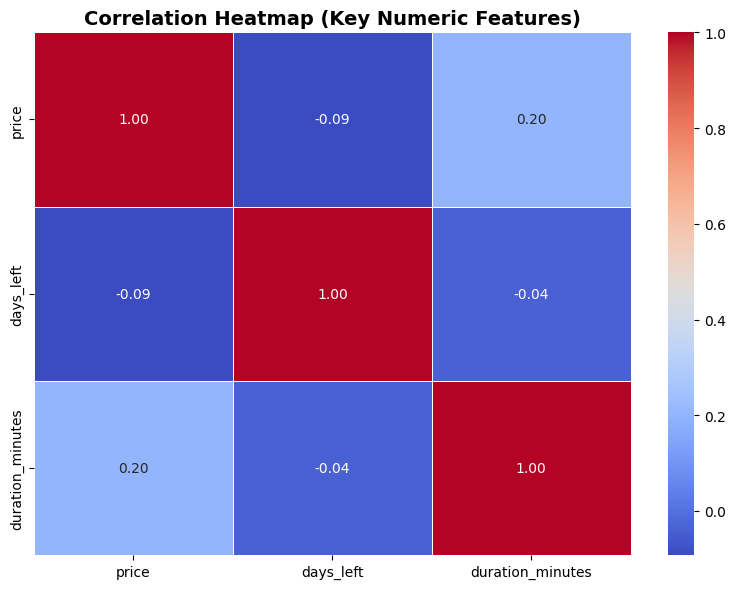

Insight: Weak numeric correlations. Price is driven by categorical variables, not just numbers.


In [6]:
corr_features = ['price', 'days_left', 'duration_minutes']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Key Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight: Weak numeric correlations. Price is driven by categorical variables, not just numbers.')

## 6. Average Price by Airline and Stops

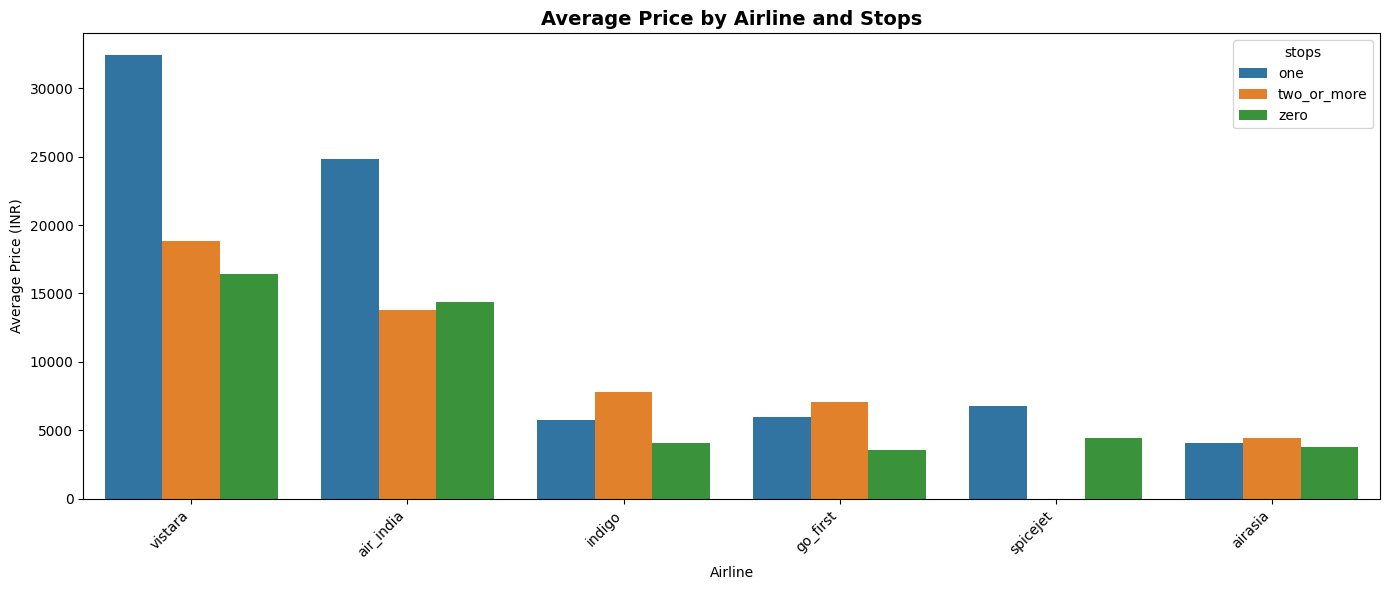

Insight: For premium airlines, one-stop flights cost MORE. For budget airlines, more stops = cheaper.


In [7]:
avg_price = df.groupby(['airline', 'stops'], as_index=False)['price'].mean().sort_values('price', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=avg_price, x='airline', y='price', hue='stops')
plt.title('Average Price by Airline and Stops', fontsize=14, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Insight: For premium airlines, one-stop flights cost MORE. For budget airlines, more stops = cheaper.')

## 7. Duration vs Price Scatter Plot

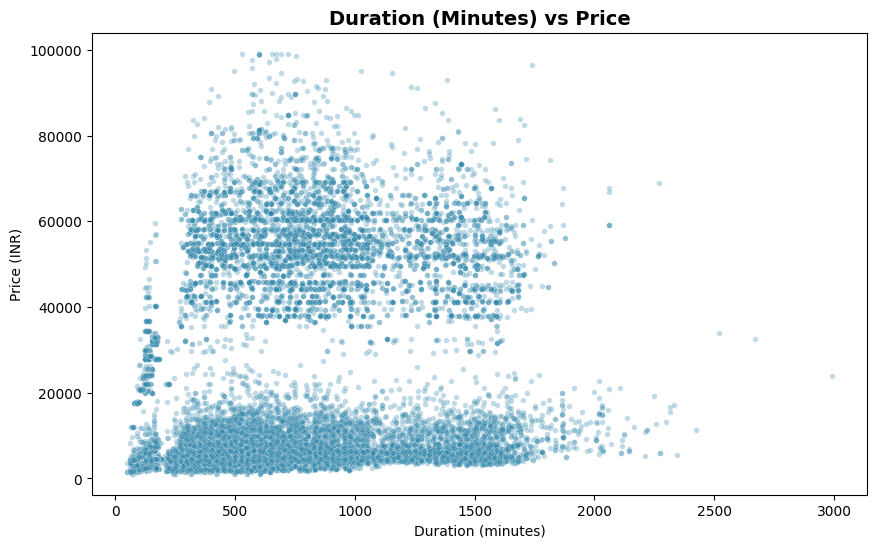

Insight: Two clusters visible — economy band below ₹20,000 and business band above ₹40,000.


In [8]:
scatter_sample = df.sample(n=min(20000, len(df)), random_state=SEED)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_sample, x='duration_minutes', y='price', alpha=0.3, s=16, color='#2E86AB')
plt.title('Duration (Minutes) vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Price (INR)')
plt.show()

print('Insight: Two clusters visible — economy band below ₹20,000 and business band above ₹40,000.')

## 8. Duration vs Price by Class

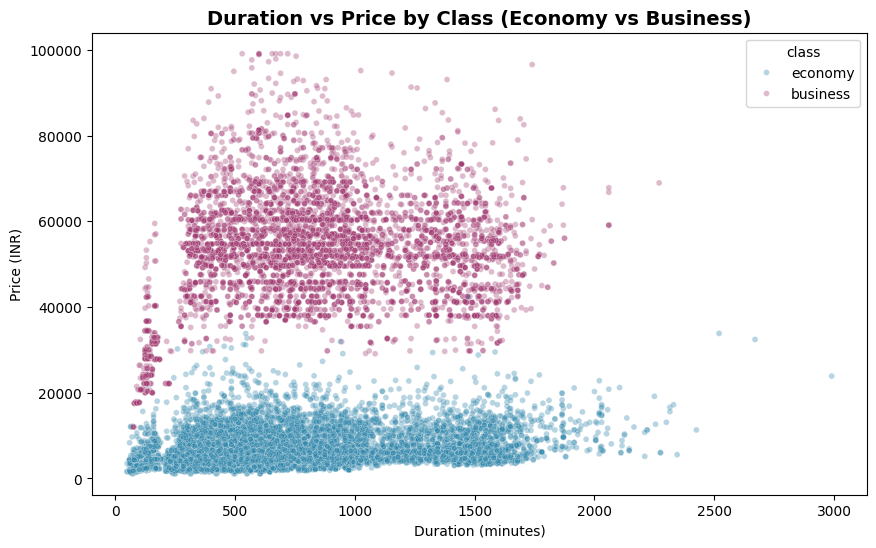

Insight: Class acts as a threshold — business class enters a completely different price regime.


In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample[scatter_sample['class'].isin(['economy', 'business'])],
    x='duration_minutes', y='price', hue='class', alpha=0.35, s=18,
    palette={'economy': '#2E86AB', 'business': '#A23B72'}
)
plt.title('Duration vs Price by Class (Economy vs Business)', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Price (INR)')
plt.show()

print('Insight: Class acts as a threshold — business class enters a completely different price regime.')

## 9. Statistical Hypothesis Testing

All tests at α = 0.05 (95% confidence level).

| Test | Question | Null Hypothesis |
|------|----------|----------------|
| Welch t-test | Are economy and business prices different? | Mean prices are equal |
| ANOVA | Do airlines charge differently? | Mean prices equal across all airlines |
| Chi-square | Are class and stops related? | Class and stops are independent |

In [10]:
# 9.1 Welch t-test: Economy vs Business
economy_prices = df.loc[df['class'] == 'economy', 'price']
business_prices = df.loc[df['class'] == 'business', 'price']

t_stat, t_p = stats.ttest_ind(economy_prices, business_prices, equal_var=False)

print(f'Welch t-test: t = {t_stat:.2f}, p = {t_p:.2e}')
print(f'Decision: {"Reject H0" if t_p < 0.05 else "Fail to reject H0"}')
print('Conclusion: Business and economy prices are significantly different.')

Welch t-test: t = -1066.76, p = 0.00e+00
Decision: Reject H0
Conclusion: Business and economy prices are significantly different.


In [11]:
# 9.2 ANOVA: Price across airlines
airline_groups = [g['price'].values for _, g in df.groupby('airline')]
f_stat, f_p = stats.f_oneway(*airline_groups)

print(f'ANOVA: F = {f_stat:.2f}, p = {f_p:.2e}')
print(f'Decision: {"Reject H0" if f_p < 0.05 else "Fail to reject H0"}')
print('Conclusion: Airlines charge significantly different average prices.')

ANOVA: F = 17033.29, p = 0.00e+00
Decision: Reject H0
Conclusion: Airlines charge significantly different average prices.


In [12]:
# 9.3 Chi-square: Class vs Stops
contingency = pd.crosstab(df['class'], df['stops'])
chi2_stat, chi2_p, chi2_dof, _ = stats.chi2_contingency(contingency)

print(f'Chi-square: χ² = {chi2_stat:.2f}, p = {chi2_p:.2e}, df = {chi2_dof}')
print(f'Decision: {"Reject H0" if chi2_p < 0.05 else "Fail to reject H0"}')
print('Conclusion: Class and number of stops are NOT independent — they are related.')
print('Contingency Table:')
display(contingency)

Chi-square: χ² = 5105.17, p = 0.00e+00, df = 2
Decision: Reject H0
Conclusion: Class and number of stops are NOT independent — they are related.
Contingency Table:


stops,one,two_or_more,zero
class,,,
business,84249,1083,7841
economy,166060,12202,26501


In [13]:
# Summary table of all tests
hypothesis_results = pd.DataFrame([
    {
        'test': 'Welch t-test (economy vs business)',
        'null_hypothesis': 'Mean prices are equal between economy and business',
        'statistic': round(t_stat, 2),
        'p_value': f'{t_p:.2e}',
        'decision': 'Reject H0' if t_p < 0.05 else 'Fail to reject H0'
    },
    {
        'test': 'ANOVA (price across airlines)',
        'null_hypothesis': 'Mean prices are equal across all airlines',
        'statistic': round(f_stat, 2),
        'p_value': f'{f_p:.2e}',
        'decision': 'Reject H0' if f_p < 0.05 else 'Fail to reject H0'
    },
    {
        'test': 'Chi-square (class vs stops)',
        'null_hypothesis': 'Class and number of stops are independent',
        'statistic': round(chi2_stat, 2),
        'p_value': f'{chi2_p:.2e}',
        'decision': 'Reject H0' if chi2_p < 0.05 else 'Fail to reject H0'
    }
])

display(hypothesis_results)
print('✅ Notebook 02 complete. Now open 03_modeling_and_evaluation.ipynb')

,test,null_hypothesis,statistic,p_value,decision
0,Welch t-test (economy vs business),Mean prices are equal between economy and busi...,-1066.76,0.00e+00,Reject H0
1,ANOVA (price across airlines),Mean prices are equal across all airlines,17033.29,0.00e+00,Reject H0
2,Chi-square (class vs stops),Class and number of stops are independent,5105.17,0.00e+00,Reject H0


✅ Notebook 02 complete. Now open 03_modeling_and_evaluation.ipynb
